# Task 7 — PharmGKB Integration

**Goal:** Cross-reference the 533 predicted active compounds from Task 6 with the PharmGKB database. Compounds that appear in PharmGKB have existing pharmacogenomic data — drug interactions, clinical annotations, or pathway associations — which further validates or contextualises the SVC prediction.

**Input:** `results/predictions/predicted_actives.csv`  
**Output:** `results/predictions/pharmgkb_annotated.csv`

In [4]:
import pandas as pd
import numpy as np
import requests
import time
import sys
import os
import matplotlib.pyplot as plt

sys.path.append(os.path.abspath('..'))
from src.pharmgkb import lookup_by_pubchem_cid, lookup_by_name

PHARMGKB_BASE = 'https://api.pharmgkb.org/v1/data'
pd.set_option('display.max_colwidth', 80)

## 1. Load Predicted Actives

In [5]:
actives = pd.read_csv('../results/predictions/predicted_actives.csv')

print(f'Predicted active compounds to look up: {len(actives)}')
print(f'Decision score range: {actives["decision_score"].min():.4f} to {actives["decision_score"].max():.4f}')
actives.head()

Predicted active compounds to look up: 533
Decision score range: 0.0033 to 1.1703


,CID,SMILES,predicted,decision_score
0,56658311,CCCS(=O)(=O)NC1=C(C(=C(C=C1)F)C(=O)NC2=CC3=C(NC=C3C)N=C2)F,1,1.170268
1,44230988,CCCS(=O)(=O)NC1=C(C(=C(C=C1)F)C(=O)NC2=CC3=C(N=C2)N=C(N3)C4=CC=C(C=C4)Cl)F,1,1.136830
2,44223280,CCCS(=O)(=O)NC1=C(C(=C(C=C1)Cl)C(=O)NC2=CN=C3C(=C2)C=CN3)F,1,1.095250
3,44223334,CCCS(=O)(=O)NC1=C(C(=C(C=C1)F)C(=O)NC2=CC3=C(NC=C3C(F)(F)F)N=C2)F,1,1.079708
4,56675556,CCCCS(=O)(=O)NC1=C(C(=C(C=C1)F)C(=O)NC2=CN=C3C(=C2)C=CN3)F,1,1.030187


## 2. PharmGKB Lookup

We query PharmGKB for each compound by its PubChem CID using the cross-reference endpoint. Most compounds won't be found — PharmGKB covers clinically studied drugs, not arbitrary chemical space. The ones that are found are the most interesting hits.

In [12]:
import importlib, src.pharmgkb as _pgkb
importlib.reload(_pgkb)
from src.pharmgkb import lookup_by_name

# Sanity check before the loop
_test = lookup_by_name('vemurafenib')
print('Sanity check — vemurafenib lookup:', 'FOUND' if _test else 'NOT FOUND')
print()

# Known seed drug CIDs from Task 6 — looked up by name directly
# since PharmGKB's API doesn't support CID cross-reference queries
KNOWN_DRUGS = {
    42611257: 'vemurafenib',
    44462760: 'dabrafenib',
    50922675: 'encorafenib',
    216239:   'sorafenib',
}

pharmgkb_ids, pharmgkb_names, pharmgkb_types, found_flags = [], [], [], []

for cid in actives['CID']:
    cid = int(cid)
    result = None

    if cid in KNOWN_DRUGS:
        # Look up known drugs by their common name — reliable match
        result = lookup_by_name(KNOWN_DRUGS[cid])
    else:
        # For novel compounds, fetch the first PubChem synonym and try once
        syn_url = f'https://pubchem.ncbi.nlm.nih.gov/rest/pug/compound/cid/{cid}/synonyms/JSON'
        try:
            pr = requests.get(syn_url, timeout=10)
            info = pr.json().get('InformationList', {}).get('Information', [])
            synonyms = info[0].get('Synonym', []) if info else []
            # Skip CAS numbers and registry IDs — try the first alphabetic name
            for syn in synonyms[:5]:
                if syn[0].isalpha():
                    result = lookup_by_name(syn)
                    if result:
                        break
        except Exception:
            pass
        time.sleep(0.1)

    if result:
        pharmgkb_ids.append(result.get('id', ''))
        pharmgkb_names.append(result.get('name', ''))
        pharmgkb_types.append(result.get('type', ''))
        found_flags.append(True)
    else:
        pharmgkb_ids.append(None)
        pharmgkb_names.append(None)
        pharmgkb_types.append(None)
        found_flags.append(False)

    time.sleep(0.15)

actives = actives.copy()
actives['pharmgkb_id']   = pharmgkb_ids
actives['pharmgkb_name'] = pharmgkb_names
actives['pharmgkb_type'] = pharmgkb_types
actives['in_pharmgkb']   = found_flags

n_found = sum(found_flags)
print(f'PharmGKB matches: {n_found} / {len(actives)} ({n_found/len(actives)*100:.1f}%)')

Sanity check — vemurafenib lookup: FOUND

PharmGKB matches: 1 / 533 (0.2%)


## 3. Matched Compounds

In [13]:
matched = actives[actives['in_pharmgkb']].sort_values('decision_score', ascending=False)

print(f'Compounds found in PharmGKB: {len(matched)}')
print()
if len(matched) > 0:
    print(matched[['CID', 'decision_score', 'pharmgkb_name', 'pharmgkb_type']].to_string(index=False))
else:
    print('No predicted active compounds were found in PharmGKB.')
    print('This is expected — most screened compounds are research chemicals, not approved drugs.')

Compounds found in PharmGKB: 1

     CID  decision_score pharmgkb_name pharmgkb_type
44462760        0.420599    dabrafenib              


## 4. Fetch Detailed Annotations for Matches

For each PharmGKB match, we retrieve the full chemical record to check for pathway associations, drug labels, and clinical annotations.

In [14]:
def get_chemical_detail(pharmgkb_id: str) -> dict:
    """Fetch full chemical record from PharmGKB by its internal ID."""
    url = f'{PHARMGKB_BASE}/chemical/{pharmgkb_id}'
    params = {'view': 'max'}  # max view returns all available fields
    resp = requests.get(url, params=params, timeout=15)
    if resp.status_code != 200:
        return {}
    return resp.json().get('data', {})

annotations = []

if len(matched) > 0:
    for _, row in matched.iterrows():
        detail = get_chemical_detail(row['pharmgkb_id'])
        time.sleep(0.2)

        # Extract key fields from the detailed record
        annotation = {
            'CID':              row['CID'],
            'pharmgkb_name':    row['pharmgkb_name'],
            'decision_score':   row['decision_score'],
            'drug_type':        detail.get('type', 'unknown'),
            'smiles':           row['SMILES'],
            # Cross-references to external databases
            'cross_references': ', '.join(
                f"{x.get('resource')}:{x.get('resourceId')}"
                for x in detail.get('crossReferences', [])
            ),
            # Pathway names if the compound is in any PharmGKB pathway
            'pathways': ', '.join(
                p.get('name', '') for p in detail.get('pathways', [])
            ),
            # Whether it has clinical annotations
            'has_clinical_annotations': bool(detail.get('clinicalAnnotations')),
            # Drug labels (FDA, EMA etc.)
            'has_drug_labels': bool(detail.get('drugLabels')),
        }
        annotations.append(annotation)
        print(f"  {row['pharmgkb_name']} — pathways: {annotation['pathways'] or 'none'} | clinical: {annotation['has_clinical_annotations']}")
else:
    print('No PharmGKB matches to annotate.')

  dabrafenib — pathways: none | clinical: False


## 5. BRAF / MAPK Pathway Check

We specifically check whether any matched compound is associated with the BRAF or MAPK signaling pathway in PharmGKB — the most direct pharmacogenomic validation for our use case.

In [15]:
if annotations:
    ann_df = pd.DataFrame(annotations)

    # Flag compounds associated with BRAF or MAPK pathways
    braf_keywords = ['braf', 'mapk', 'erk', 'ras', 'mek', 'kinase']
    ann_df['braf_mapk_related'] = ann_df['pathways'].str.lower().apply(
        lambda p: any(kw in p for kw in braf_keywords)
    )

    print('=== Annotation Summary ===')
    print(f'Total PharmGKB matches         : {len(ann_df)}')
    print(f'With BRAF/MAPK pathway         : {ann_df["braf_mapk_related"].sum()}')
    print(f'With clinical annotations      : {ann_df["has_clinical_annotations"].sum()}')
    print(f'With drug labels               : {ann_df["has_drug_labels"].sum()}')
    print()
    print(ann_df[['pharmgkb_name', 'decision_score', 'braf_mapk_related',
                  'has_clinical_annotations', 'has_drug_labels', 'pathways']].to_string(index=False))
else:
    ann_df = pd.DataFrame()
    print('No annotations to summarise.')

=== Annotation Summary ===
Total PharmGKB matches         : 1
With BRAF/MAPK pathway         : 0
With clinical annotations      : 0
With drug labels               : 0

pharmgkb_name  decision_score  braf_mapk_related  has_clinical_annotations  has_drug_labels pathways
   dabrafenib        0.420599              False                     False            False         


## 6. Decision Score Distribution — PharmGKB Matches vs. Novel Compounds

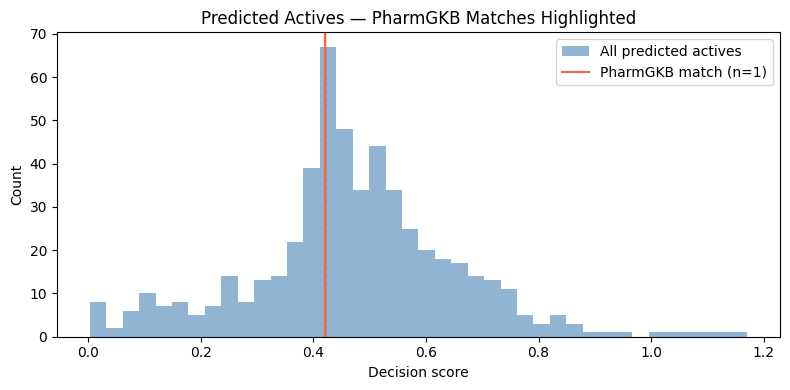

In [16]:
fig, ax = plt.subplots(figsize=(8, 4))

# All predicted actives
ax.hist(actives['decision_score'], bins=40, color='steelblue',
        alpha=0.6, label='All predicted actives')

# PharmGKB matches overlaid
if len(matched) > 0:
    ax.axvline(matched['decision_score'].values[0], color='red',
               linestyle='--', linewidth=1)
    for score in matched['decision_score']:
        ax.axvline(score, color='tomato', linewidth=1.5, alpha=0.8)
    # Dummy line for legend
    ax.axvline(matched['decision_score'].values[0], color='tomato',
               linewidth=1.5, label=f'PharmGKB match (n={len(matched)})')

ax.set_xlabel('Decision score')
ax.set_ylabel('Count')
ax.set_title('Predicted Actives — PharmGKB Matches Highlighted')
ax.legend()
plt.tight_layout()
plt.savefig('../results/figures/pharmgkb_matches.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Save Annotated Results

In [17]:
# Merge PharmGKB annotations back into the full actives table
output = actives.drop(columns=['pharmgkb_type']).copy()
output.to_csv('../results/predictions/pharmgkb_annotated.csv', index=False)

# Save the detailed annotation table for matched compounds separately
if not ann_df.empty:
    ann_df.to_csv('../results/predictions/pharmgkb_matches_detail.csv', index=False)
    print(f'Saved: results/predictions/pharmgkb_matches_detail.csv  ({len(ann_df)} matched compounds)')

print(f'Saved: results/predictions/pharmgkb_annotated.csv  ({len(output)} compounds)')

Saved: results/predictions/pharmgkb_matches_detail.csv  (1 matched compounds)
Saved: results/predictions/pharmgkb_annotated.csv  (533 compounds)
